# Event Impact Modeling

In [1]:
from pathlib import Path
import sys


current_path = Path.cwd().resolve()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)

Project root: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast


In [2]:
import pandas as pd

from src.data_loader import load_enriched_data
from src.data_explorer import get_impact_link_details


enriched_df = load_enriched_data()

print("Dataset shape:", enriched_df.shape)

Dataset shape: (86, 35)


In [3]:
events_df = enriched_df[
    enriched_df["record_type"] == "event"
].copy()

impact_links_df = enriched_df[
    enriched_df["record_type"] == "impact_link"
].copy()

print("Events:", len(events_df))
print("Impact links:", len(impact_links_df))

Events: 15
Impact links: 23


In [4]:
impact_details = get_impact_link_details(
    enriched_df
)

impact_details.head()

,record_id,parent_id,event_name,event_date,event_category,pillar,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,confidence
0,IMP_0001,EVT_0001,Telebirr Launch,2021-05-17,product_launch,ACCESS,ACC_OWNERSHIP,direct,increase,high,15.0,12.0,literature,Kenya,medium
1,IMP_0002,EVT_0001,Telebirr Launch,2021-05-17,product_launch,USAGE,USG_TELEBIRR_USERS,direct,increase,high,NaN,3.0,empirical,NaN,high
2,IMP_0003,EVT_0001,Telebirr Launch,2021-05-17,product_launch,USAGE,USG_P2P_COUNT,direct,increase,high,25.0,6.0,empirical,NaN,medium
3,IMP_0004,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01,market_entry,ACCESS,ACC_4G_COV,direct,increase,medium,15.0,12.0,empirical,NaN,medium
4,IMP_0005,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01,market_entry,AFFORDABILITY,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12.0,literature,Rwanda,medium


In [ ]:
impact_model_data = impact_details[
    [
        "record_id",
        "parent_id",
        "event_name",
        "event_date",
        "event_category",
        "pillar",
        "related_indicator",
        "relationship_type",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "evidence_basis",
        "confidence",
    ]
].copy()

impact_model_data = impact_model_data.sort_values(
    [
        "event_date",
        "related_indicator",
    ]
).reset_index(drop=True)

impact_model_data

,record_id,parent_id,event_name,event_date,event_category,pillar,related_indicator,relationship_type,impact_direction,impact_magnitude,lag_months,evidence_basis,confidence
0,IMP_0001,EVT_0001,Telebirr Launch,2021-05-17,product_launch,ACCESS,ACC_OWNERSHIP,direct,increase,high,12.0,literature,medium
1,IMP_0003,EVT_0001,Telebirr Launch,2021-05-17,product_launch,USAGE,USG_P2P_COUNT,direct,increase,high,6.0,empirical,medium
2,IMP_0002,EVT_0001,Telebirr Launch,2021-05-17,product_launch,USAGE,USG_TELEBIRR_USERS,direct,increase,high,3.0,empirical,high
3,IMP_0004,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01,market_entry,ACCESS,ACC_4G_COV,direct,increase,medium,12.0,empirical,medium
4,IMP_0005,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01,market_entry,AFFORDABILITY,AFF_DATA_INCOME,indirect,decrease,medium,12.0,literature,medium
5,IMP_0007,EVT_0003,M-Pesa Ethiopia Launch,2023-08-01,product_launch,ACCESS,ACC_MM_ACCOUNT,direct,increase,medium,6.0,theoretical,medium
6,IMP_0006,EVT_0003,M-Pesa Ethiopia Launch,2023-08-01,product_launch,USAGE,USG_MPESA_USERS,direct,increase,high,3.0,empirical,high
7,IMP_0015,EVT_0011,Revised Payment Instrument Issuer Directive,2023-10-09,regulation,ACCESS,ACC_MM_ACCOUNT,direct,increase,medium,6.0,theoretical,medium
8,IMP_0016,EVT_0011,Revised Payment Instrument Issuer Directive,2023-10-09,regulation,USAGE,USG_SECTOR_ACTIVE_ACCOUNT_RATE,enabling,increase,medium,12.0,theoretical,medium
9,IMP_0008,EVT_0004,Fayda Digital ID Program Rollout,2024-01-01,infrastructure,ACCESS,ACC_OWNERSHIP,enabling,increase,medium,24.0,literature,medium


## event-impact summary

In [8]:
event_impact_summary = impact_model_data[
    [
        "event_name",
        "event_date",
        "event_category",
        "pillar",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "confidence",
    ]
].copy()

event_impact_summary

,event_name,event_date,event_category,pillar,related_indicator,impact_direction,impact_magnitude,lag_months,confidence
0,Telebirr Launch,2021-05-17,product_launch,ACCESS,ACC_OWNERSHIP,increase,high,12.0,medium
1,Telebirr Launch,2021-05-17,product_launch,USAGE,USG_P2P_COUNT,increase,high,6.0,medium
2,Telebirr Launch,2021-05-17,product_launch,USAGE,USG_TELEBIRR_USERS,increase,high,3.0,high
3,Safaricom Ethiopia Commercial Launch,2022-08-01,market_entry,ACCESS,ACC_4G_COV,increase,medium,12.0,medium
4,Safaricom Ethiopia Commercial Launch,2022-08-01,market_entry,AFFORDABILITY,AFF_DATA_INCOME,decrease,medium,12.0,medium
5,M-Pesa Ethiopia Launch,2023-08-01,product_launch,ACCESS,ACC_MM_ACCOUNT,increase,medium,6.0,medium
6,M-Pesa Ethiopia Launch,2023-08-01,product_launch,USAGE,USG_MPESA_USERS,increase,high,3.0,high
7,Revised Payment Instrument Issuer Directive,2023-10-09,regulation,ACCESS,ACC_MM_ACCOUNT,increase,medium,6.0,medium
8,Revised Payment Instrument Issuer Directive,2023-10-09,regulation,USAGE,USG_SECTOR_ACTIVE_ACCOUNT_RATE,increase,medium,12.0,medium
9,Fayda Digital ID Program Rollout,2024-01-01,infrastructure,ACCESS,ACC_OWNERSHIP,increase,medium,24.0,medium


In [10]:
def describe_impact(row):
    direction = str(row["impact_direction"]).lower()
    magnitude = str(row["impact_magnitude"]).lower()


    return (
        f"{direction.capitalize()} effect, "
        f"{magnitude} magnitude; "
        f"lag of {row['lag_months']} months"
    )


event_impact_summary["impact_description"] = (
    event_impact_summary.apply(
        describe_impact,
        axis=1,
    )
)

event_impact_summary[
    [
        "event_name",
        "related_indicator",
        "pillar",
        "impact_description",
        "confidence",
    ]
]

,event_name,related_indicator,pillar,impact_description,confidence
0,Telebirr Launch,ACC_OWNERSHIP,ACCESS,"Increase effect, high magnitude; lag of 12.0 m...",medium
1,Telebirr Launch,USG_P2P_COUNT,USAGE,"Increase effect, high magnitude; lag of 6.0 mo...",medium
2,Telebirr Launch,USG_TELEBIRR_USERS,USAGE,"Increase effect, high magnitude; lag of 3.0 mo...",high
3,Safaricom Ethiopia Commercial Launch,ACC_4G_COV,ACCESS,"Increase effect, medium magnitude; lag of 12.0...",medium
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,AFFORDABILITY,"Decrease effect, medium magnitude; lag of 12.0...",medium
5,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,ACCESS,"Increase effect, medium magnitude; lag of 6.0 ...",medium
6,M-Pesa Ethiopia Launch,USG_MPESA_USERS,USAGE,"Increase effect, high magnitude; lag of 3.0 mo...",high
7,Revised Payment Instrument Issuer Directive,ACC_MM_ACCOUNT,ACCESS,"Increase effect, medium magnitude; lag of 6.0 ...",medium
8,Revised Payment Instrument Issuer Directive,USG_SECTOR_ACTIVE_ACCOUNT_RATE,USAGE,"Increase effect, medium magnitude; lag of 12.0...",medium
9,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,ACCESS,"Increase effect, medium magnitude; lag of 24.0...",medium


In [11]:
events_to_indicators = (
    event_impact_summary
    .groupby(
        [
            "event_name",
            "event_category",
        ],
        dropna=False,
    )
    .agg(
        affected_indicators=(
            "related_indicator",
            lambda values: ", ".join(
                sorted(values.unique())
            ),
        ),
        number_of_links=(
            "related_indicator",
            "count",
        ),
        maximum_lag_months=(
            "lag_months",
            "max",
        ),
    )
    .reset_index()
    .sort_values(
        "number_of_links",
        ascending=False,
    )
)

events_to_indicators

,event_name,event_category,affected_indicators,number_of_links,maximum_lag_months
12,Telebirr Launch,product_launch,"ACC_OWNERSHIP, USG_P2P_COUNT, USG_TELEBIRR_USERS",3,12.0
4,M-Pesa EthSwitch Integration,partnership,"USG_MPESA_ACTIVE, USG_P2P_COUNT",2,3.0
3,ISO 20022 EATS Payment System Upgrade,infrastructure,"USG_DIGITAL_TXN_VALUE, USG_P2P_COUNT",2,12.0
5,M-Pesa Ethiopia Launch,product_launch,"ACC_MM_ACCOUNT, USG_MPESA_USERS",2,6.0
1,Fayda Digital ID Program Rollout,infrastructure,"ACC_OWNERSHIP, GEN_GAP_ACC",2,24.0
10,Safaricom Ethiopia Commercial Launch,market_entry,"ACC_4G_COV, AFF_DATA_INCOME",2,12.0
9,Revised Payment Instrument Issuer Directive,regulation,"ACC_MM_ACCOUNT, USG_SECTOR_ACTIVE_ACCOUNT_RATE",2,12.0
8,National Interoperable QR Payment Standard Launch,regulation,"USG_DIGITAL_PAYMENT_RATE, USG_POS_COUNT",2,12.0
6,National Digital Payments Strategy Phase Two L...,policy,"ACC_OWNERSHIP, USG_DIGITAL_PAYMENT_RATE",2,12.0
2,Foreign Exchange Liberalization,policy,AFF_DATA_INCOME,1,3.0


In [13]:
from src.config import PROCESSED_DATA_DIR


impact_model_path = (
    PROCESSED_DATA_DIR
    / "event_impact_model_data.csv"
)

impact_model_data.to_csv(
    impact_model_path,
    index=False,
)

print(
    "Saved to:",
    impact_model_path,
)

Saved to: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\data\processed\event_impact_model_data.csv


In [16]:
print("=" * 60)
print("EVENT IMPACT DATA SUMMARY")
print("=" * 60)

print(
    "\nCataloged events:",
    len(events_df),
)

print(
    "Impact links:",
    len(impact_links_df),
)

print(
    "Events represented in impact links:",
    impact_model_data[
        "parent_id"
    ].nunique(),
)

print(
    "Affected indicators:",
    impact_model_data[
        "related_indicator"
    ].nunique(),
)

print(
    "\nModeling data saved to:",
    impact_model_path,
)

EVENT IMPACT DATA SUMMARY

Cataloged events: 15
Impact links: 23
Events represented in impact links: 13
Affected indicators: 13

Modeling data saved to: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\data\processed\event_impact_model_data.csv


# Event–Indicator Matrix

In [17]:
direction_scores = {
    "increase": 1,
    "decrease": -1,
    "no_change": 0,
}

magnitude_scores = {
    "low": 1,
    "medium": 2,
    "high": 3,
}

event_indicator_links = (
    impact_model_data.copy()
)

event_indicator_links[
    "direction_score"
] = (
    event_indicator_links[
        "impact_direction"
    ]
    .str.lower()
    .map(direction_scores)
)

event_indicator_links[
    "magnitude_score"
] = (
    event_indicator_links[
        "impact_magnitude"
    ]
    .str.lower()
    .map(magnitude_scores)
)

event_indicator_links[
    "signed_effect_score"
] = (
    event_indicator_links[
        "direction_score"
    ]
    * event_indicator_links[
        "magnitude_score"
    ]
)

event_indicator_links[
    [
        "event_name",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "signed_effect_score",
    ]
]

,event_name,related_indicator,impact_direction,impact_magnitude,lag_months,signed_effect_score
0,Telebirr Launch,ACC_OWNERSHIP,increase,high,12.0,3
1,Telebirr Launch,USG_P2P_COUNT,increase,high,6.0,3
2,Telebirr Launch,USG_TELEBIRR_USERS,increase,high,3.0,3
3,Safaricom Ethiopia Commercial Launch,ACC_4G_COV,increase,medium,12.0,2
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,decrease,medium,12.0,-2
5,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,increase,medium,6.0,2
6,M-Pesa Ethiopia Launch,USG_MPESA_USERS,increase,high,3.0,3
7,Revised Payment Instrument Issuer Directive,ACC_MM_ACCOUNT,increase,medium,6.0,2
8,Revised Payment Instrument Issuer Directive,USG_SECTOR_ACTIVE_ACCOUNT_RATE,increase,medium,12.0,2
9,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,increase,medium,24.0,2


In [18]:
event_indicator_matrix = (
    event_indicator_links
    .pivot_table(
        index=[
            "parent_id",
            "event_name",
            "event_date",
        ],
        columns="related_indicator",
        values="signed_effect_score",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)

event_indicator_matrix

related_indicator,parent_id,event_name,event_date,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_DIGITAL_PAYMENT_RATE,USG_DIGITAL_TXN_VALUE,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_POS_COUNT,USG_SECTOR_ACTIVE_ACCOUNT_RATE,USG_TELEBIRR_USERS
0,EVT_0001,Telebirr Launch,2021-05-17,0,0,3,0,0,0,0,0,0,3,0,0,3
1,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01,2,0,0,-2,0,0,0,0,0,0,0,0,0
2,EVT_0003,M-Pesa Ethiopia Launch,2023-08-01,0,2,0,0,0,0,0,0,3,0,0,0,0
3,EVT_0004,Fayda Digital ID Program Rollout,2024-01-01,0,0,2,0,-2,0,0,0,0,0,0,0,0
4,EVT_0005,Foreign Exchange Liberalization,2024-07-29,0,0,0,3,0,0,0,0,0,0,0,0,0
5,EVT_0007,M-Pesa EthSwitch Integration,2025-10-27,0,0,0,0,0,0,0,2,0,2,0,0,0
6,EVT_0008,EthioPay Instant Payment System Launch,2025-12-18,0,0,0,0,0,0,0,0,0,2,0,0,0
7,EVT_0010,Safaricom Ethiopia Price Increase,2025-12-15,0,0,0,1,0,0,0,0,0,0,0,0,0
8,EVT_0011,Revised Payment Instrument Issuer Directive,2023-10-09,0,2,0,0,0,0,0,0,0,0,0,2,0
9,EVT_0012,National Financial Education Module Launch,2024-02-29,0,0,0,0,0,1,0,0,0,0,0,0,0


In [19]:
event_indicator_links[
    "event_date"
] = pd.to_datetime(
    event_indicator_links["event_date"]
)

event_indicator_links[
    "lag_months"
] = pd.to_numeric(
    event_indicator_links["lag_months"],
    errors="coerce",
).fillna(0).astype(int)

In [20]:
def calculate_event_effect(
    event_date,
    current_date,
    lag_months,
    effect_score,
    build_months=12,
):
    """
    Calculate an event's effect at a given date.

    The effect begins after the specified lag
    and builds gradually over build_months.
    """

    effect_start = (
        event_date
        + pd.DateOffset(
            months=int(lag_months)
        )
    )

    if current_date < effect_start:
        return 0

    months_since_start = (
        (current_date.year - effect_start.year)
        * 12
        + current_date.month
        - effect_start.month
    )

    build_factor = min(
        (months_since_start + 1)
        / build_months,
        1,
    )

    return (
        effect_score
        * build_factor
    )

In [21]:
model_start = (
    event_indicator_links[
        "event_date"
    ]
    .min()
    .to_period("M")
    .to_timestamp()
)

model_end = pd.Timestamp(
    "2027-12-01"
)

model_dates = pd.date_range(
    start=model_start,
    end=model_end,
    freq="MS",
)

effect_records = []

for _, link in (
    event_indicator_links.iterrows()
):

    for current_date in model_dates:

        effect_score = (
            calculate_event_effect(
                event_date=link["event_date"],
                current_date=current_date,
                lag_months=link["lag_months"],
                effect_score=link[
                    "signed_effect_score"
                ],
            )
        )

        effect_records.append({
            "date": current_date,
            "parent_id": link["parent_id"],
            "event_name": link["event_name"],
            "related_indicator": link[
                "related_indicator"
            ],
            "event_effect_score": round(
                effect_score,
                3,
            ),
        })

event_effects_monthly = pd.DataFrame(
    effect_records
)

event_effects_monthly.head()

,date,parent_id,event_name,related_indicator,event_effect_score
0,2021-05-01,EVT_0001,Telebirr Launch,ACC_OWNERSHIP,0.0
1,2021-06-01,EVT_0001,Telebirr Launch,ACC_OWNERSHIP,0.0
2,2021-07-01,EVT_0001,Telebirr Launch,ACC_OWNERSHIP,0.0
3,2021-08-01,EVT_0001,Telebirr Launch,ACC_OWNERSHIP,0.0
4,2021-09-01,EVT_0001,Telebirr Launch,ACC_OWNERSHIP,0.0


In [22]:
combined_indicator_effects = (
    event_effects_monthly
    .groupby(
        [
            "date",
            "related_indicator",
        ],
        as_index=False,
    )
    .agg(
        combined_effect_score=(
            "event_effect_score",
            "sum",
        ),
        active_event_count=(
            "event_effect_score",
            lambda values: (
                values != 0
            ).sum(),
        ),
    )
)

combined_indicator_effects.head()

,date,related_indicator,combined_effect_score,active_event_count
0,2021-05-01,ACC_4G_COV,0.0,0
1,2021-05-01,ACC_MM_ACCOUNT,0.0,0
2,2021-05-01,ACC_OWNERSHIP,0.0,0
3,2021-05-01,AFF_DATA_INCOME,0.0,0
4,2021-05-01,GEN_GAP_ACC,0.0,0


In [24]:
account_ownership_effects = (
    combined_indicator_effects[
        combined_indicator_effects[
            "related_indicator"
        ] == "ACC_OWNERSHIP"
    ]
    .reset_index(drop=True)
)

account_ownership_effects.tail(24)

,date,related_indicator,combined_effect_score,active_event_count
56,2026-01-01,ACC_OWNERSHIP,3.167,2
57,2026-02-01,ACC_OWNERSHIP,3.333,2
58,2026-03-01,ACC_OWNERSHIP,3.500,2
59,2026-04-01,ACC_OWNERSHIP,4.000,3
60,2026-05-01,ACC_OWNERSHIP,4.333,3
61,2026-06-01,ACC_OWNERSHIP,4.667,3
62,2026-07-01,ACC_OWNERSHIP,5.000,3
63,2026-08-01,ACC_OWNERSHIP,5.333,3
64,2026-09-01,ACC_OWNERSHIP,5.667,3
65,2026-10-01,ACC_OWNERSHIP,6.000,3


In [26]:
print("=" * 60)
print("EVENT–INDICATOR MATRIX SUMMARY")
print("=" * 60)

print(
    "\nEvents in matrix:",
    event_indicator_matrix[
        "parent_id"
    ].nunique(),
)

print(
    "Indicators affected:",
    event_indicator_links[
        "related_indicator"
    ].nunique(),
)

print(
    "Impact links modeled:",
    len(event_indicator_links),
)

print(
    "Monthly effect records:",
    len(event_effects_monthly),
)

print(
    "Combined indicator-month records:",
    len(combined_indicator_effects),
)

print(
    "\nEffect representation:",
    "Delayed, gradual 12-month build"
)

print(
    "Multiple-event rule:",
    "Signed effects are added"
)

EVENT–INDICATOR MATRIX SUMMARY

Events in matrix: 13
Indicators affected: 13
Impact links modeled: 23
Monthly effect records: 1840
Combined indicator-month records: 1040

Effect representation: Delayed, gradual 12-month build
Multiple-event rule: Signed effects are added


## Comparable-Country Evidence

In [27]:
comparable_evidence = pd.DataFrame([
    {
        "evidence_id": "COMP_001",
        "country": "Kenya",
        "comparable_event": "M-Pesa expansion",
        "event_type": "product_launch",
        "relevant_indicators": (
            "ACC_MM_ACCOUNT, ACC_OWNERSHIP"
        ),
        "documented_impact": (
            "Mobile money expansion improved financial access "
            "and produced measurable household welfare effects."
        ),
        "observed_direction": "increase",
        "suggested_magnitude": "high",
        "suggested_lag_months": 24,
        "transferability": "medium",
        "calibration_use": (
            "Supports a strong positive long-run effect on "
            "mobile money access, but not an immediate equal "
            "increase in total account ownership."
        ),
        "source_url": (
            "https://www.science.org/doi/10.1126/science.aah5309"
        ),
    },

    {
        "evidence_id": "COMP_002",
        "country": "India",
        "comparable_event": (
            "Financial inclusion policy combined with "
            "digital identification"
        ),
        "event_type": "policy_and_digital_id",
        "relevant_indicators": (
            "ACC_OWNERSHIP, ACC_FAYDA"
        ),
        "documented_impact": (
            "Account ownership increased from 35.2% in 2011 "
            "to 79.9% in 2017 during large-scale account-opening "
            "and digital identification programmes."
        ),
        "observed_direction": "increase",
        "suggested_magnitude": "high",
        "suggested_lag_months": 24,
        "transferability": "medium",
        "calibration_use": (
            "Supports a positive Access effect when digital ID "
            "is combined with account-opening policy and delivery."
        ),
        "source_url": (
            "https://databank.worldbank.org/embed/"
            "Account-Ownership/id/9ba1567e"
        ),
    },

    {
        "evidence_id": "COMP_003",
        "country": "Tanzania",
        "comparable_event": (
            "Mobile money account-to-account interoperability"
        ),
        "event_type": "partnership",
        "relevant_indicators": (
            "USG_P2P_COUNT, USG_ACTIVE_RATE"
        ),
        "documented_impact": (
            "Cross-network transactions exceeded off-network "
            "voucher transfers, with participating providers "
            "reporting double-digit monthly growth."
        ),
        "observed_direction": "increase",
        "suggested_magnitude": "medium",
        "suggested_lag_months": 6,
        "transferability": "high",
        "calibration_use": (
            "Supports a medium positive effect of interoperability "
            "on P2P activity and active usage."
        ),
        "source_url": (
            "https://www.gsma.com/solutions-and-impact/"
            "connectivity-for-good/mobile-for-development/"
            "uncategorized/new-publication-explores-the-impact-"
            "of-mobile-money-interoperability-in-tanzania/"
        ),
    },

    {
        "evidence_id": "COMP_004",
        "country": "Ghana",
        "comparable_event": "Electronic transaction levy",
        "event_type": "pricing",
        "relevant_indicators": (
            "USG_P2P_COUNT, USG_DIGITAL_PAYMENT_RATE"
        ),
        "documented_impact": (
            "Mobile money use fell by about 25% immediately "
            "after the levy, while transaction values and provider "
            "revenues fell by as much as 35% year-on-year."
        ),
        "observed_direction": "decrease",
        "suggested_magnitude": "high",
        "suggested_lag_months": 0,
        "transferability": "medium",
        "calibration_use": (
            "Supports an immediate negative Usage effect from "
            "substantial transaction-price increases."
        ),
        "source_url": (
            "https://www.gsma.com/solutions-and-impact/"
            "connectivity-for-good/public-policy/"
            "the-e-levy-in-ghana-measuring-the-impacts-on-"
            "financial-inclusion-and-the-digital-economy/"
        ),
    },

    {
        "evidence_id": "COMP_005",
        "country": "International",
        "comparable_event": "ISO 20022 adoption",
        "event_type": "infrastructure",
        "relevant_indicators": (
            "USG_DIGITAL_TXN_VALUE, USG_P2P_COUNT"
        ),
        "documented_impact": (
            "Structured payment data can improve processing, "
            "interoperability, transparency, compliance, and "
            "straight-through processing."
        ),
        "observed_direction": "increase",
        "suggested_magnitude": "low",
        "suggested_lag_months": 12,
        "transferability": "medium",
        "calibration_use": (
            "Supports an enabling effect, but does not provide "
            "a direct numerical increase in payment activity."
        ),
        "source_url": (
            "https://www.bis.org/cpmi/publ/d218.htm"
        ),
    },
])

comparable_evidence

,evidence_id,country,comparable_event,event_type,relevant_indicators,documented_impact,observed_direction,suggested_magnitude,suggested_lag_months,transferability,calibration_use,source_url
0,COMP_001,Kenya,M-Pesa expansion,product_launch,"ACC_MM_ACCOUNT, ACC_OWNERSHIP",Mobile money expansion improved financial acce...,increase,high,24,medium,Supports a strong positive long-run effect on ...,https://www.science.org/doi/10.1126/science.aa...
1,COMP_002,India,Financial inclusion policy combined with digit...,policy_and_digital_id,"ACC_OWNERSHIP, ACC_FAYDA",Account ownership increased from 35.2% in 2011...,increase,high,24,medium,Supports a positive Access effect when digital...,https://databank.worldbank.org/embed/Account-O...
2,COMP_003,Tanzania,Mobile money account-to-account interoperability,partnership,"USG_P2P_COUNT, USG_ACTIVE_RATE",Cross-network transactions exceeded off-networ...,increase,medium,6,high,Supports a medium positive effect of interoper...,https://www.gsma.com/solutions-and-impact/conn...
3,COMP_004,Ghana,Electronic transaction levy,pricing,"USG_P2P_COUNT, USG_DIGITAL_PAYMENT_RATE",Mobile money use fell by about 25% immediately...,decrease,high,0,medium,Supports an immediate negative Usage effect fr...,https://www.gsma.com/solutions-and-impact/conn...
4,COMP_005,International,ISO 20022 adoption,infrastructure,"USG_DIGITAL_TXN_VALUE, USG_P2P_COUNT",Structured payment data can improve processing...,increase,low,12,medium,"Supports an enabling effect, but does not prov...",https://www.bis.org/cpmi/publ/d218.htm


In [28]:
comparable_evidence_summary = comparable_evidence[
    [
        "evidence_id",
        "country",
        "comparable_event",
        "relevant_indicators",
        "observed_direction",
        "suggested_magnitude",
        "suggested_lag_months",
        "transferability",
    ]
]

comparable_evidence_summary

,evidence_id,country,comparable_event,relevant_indicators,observed_direction,suggested_magnitude,suggested_lag_months,transferability
0,COMP_001,Kenya,M-Pesa expansion,"ACC_MM_ACCOUNT, ACC_OWNERSHIP",increase,high,24,medium
1,COMP_002,India,Financial inclusion policy combined with digit...,"ACC_OWNERSHIP, ACC_FAYDA",increase,high,24,medium
2,COMP_003,Tanzania,Mobile money account-to-account interoperability,"USG_P2P_COUNT, USG_ACTIVE_RATE",increase,medium,6,high
3,COMP_004,Ghana,Electronic transaction levy,"USG_P2P_COUNT, USG_DIGITAL_PAYMENT_RATE",decrease,high,0,medium
4,COMP_005,International,ISO 20022 adoption,"USG_DIGITAL_TXN_VALUE, USG_P2P_COUNT",increase,low,12,medium


In [29]:
evidence_mapping = {
    "ACC_MM_ACCOUNT": "COMP_001",
    "ACC_FAYDA": "COMP_002",
    "ACC_OWNERSHIP": "COMP_002",
    "USG_P2P_COUNT": "COMP_003",
    "USG_ACTIVE_RATE": "COMP_003",
    "USG_DIGITAL_PAYMENT_RATE": "COMP_004",
    "USG_DIGITAL_TXN_VALUE": "COMP_005",
}

event_indicator_links[
    "comparable_evidence_id"
] = (
    event_indicator_links[
        "related_indicator"
    ].map(evidence_mapping)
)

In [30]:
event_indicator_links = (
    event_indicator_links.merge(
        comparable_evidence[
            [
                "evidence_id",
                "country",
                "documented_impact",
                "transferability",
                "calibration_use",
            ]
        ],
        left_on="comparable_evidence_id",
        right_on="evidence_id",
        how="left",
    )
)

event_indicator_links[
    [
        "event_name",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "country",
        "transferability",
        "calibration_use",
    ]
]

,event_name,related_indicator,impact_direction,impact_magnitude,lag_months,country,transferability,calibration_use
0,Telebirr Launch,ACC_OWNERSHIP,increase,high,12,India,medium,Supports a positive Access effect when digital...
1,Telebirr Launch,USG_P2P_COUNT,increase,high,6,Tanzania,high,Supports a medium positive effect of interoper...
2,Telebirr Launch,USG_TELEBIRR_USERS,increase,high,3,NaN,NaN,NaN
3,Safaricom Ethiopia Commercial Launch,ACC_4G_COV,increase,medium,12,NaN,NaN,NaN
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,decrease,medium,12,NaN,NaN,NaN
5,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,increase,medium,6,Kenya,medium,Supports a strong positive long-run effect on ...
6,M-Pesa Ethiopia Launch,USG_MPESA_USERS,increase,high,3,NaN,NaN,NaN
7,Revised Payment Instrument Issuer Directive,ACC_MM_ACCOUNT,increase,medium,6,Kenya,medium,Supports a strong positive long-run effect on ...
8,Revised Payment Instrument Issuer Directive,USG_SECTOR_ACTIVE_ACCOUNT_RATE,increase,medium,12,NaN,NaN,NaN
9,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,increase,medium,24,India,medium,Supports a positive Access effect when digital...


In [31]:
def compare_direction(row):
    if pd.isna(row["observed_direction"]):
        return "No comparable evidence"

    if (
        str(row["impact_direction"]).lower()
        == str(row["observed_direction"]).lower()
    ):
        return "Direction supported"

    return "Direction differs"


evidence_review = (
    event_indicator_links.merge(
        comparable_evidence[
            [
                "evidence_id",
                "observed_direction",
                "suggested_magnitude",
                "suggested_lag_months",
            ]
        ],
        on="evidence_id",
        how="left",
    )
)

evidence_review[
    "direction_review"
] = evidence_review.apply(
    compare_direction,
    axis=1,
)

evidence_review[
    [
        "event_name",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "observed_direction",
        "suggested_magnitude",
        "suggested_lag_months",
        "direction_review",
    ]
]

,event_name,related_indicator,impact_direction,impact_magnitude,lag_months,observed_direction,suggested_magnitude,suggested_lag_months,direction_review
0,Telebirr Launch,ACC_OWNERSHIP,increase,high,12,increase,high,24.0,Direction supported
1,Telebirr Launch,USG_P2P_COUNT,increase,high,6,increase,medium,6.0,Direction supported
2,Telebirr Launch,USG_TELEBIRR_USERS,increase,high,3,NaN,NaN,NaN,No comparable evidence
3,Safaricom Ethiopia Commercial Launch,ACC_4G_COV,increase,medium,12,NaN,NaN,NaN,No comparable evidence
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,decrease,medium,12,NaN,NaN,NaN,No comparable evidence
5,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,increase,medium,6,increase,high,24.0,Direction supported
6,M-Pesa Ethiopia Launch,USG_MPESA_USERS,increase,high,3,NaN,NaN,NaN,No comparable evidence
7,Revised Payment Instrument Issuer Directive,ACC_MM_ACCOUNT,increase,medium,6,increase,high,24.0,Direction supported
8,Revised Payment Instrument Issuer Directive,USG_SECTOR_ACTIVE_ACCOUNT_RATE,increase,medium,12,NaN,NaN,NaN,No comparable evidence
9,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,increase,medium,24,increase,high,24.0,Direction supported


In [32]:
print("=" * 60)
print("COMPARABLE-COUNTRY EVIDENCE SUMMARY")
print("=" * 60)

print(
    "\nComparable cases reviewed:",
    len(comparable_evidence),
)

print(
    "Countries or contexts:",
    comparable_evidence["country"].nunique(),
)

print(
    "Impact links with comparable evidence:",
    event_indicator_links[
        "comparable_evidence_id"
    ].notna().sum(),
)

print(
    "Impact links without comparable evidence:",
    event_indicator_links[
        "comparable_evidence_id"
    ].isna().sum(),
)

print(
    "\nImportant interpretation:",
    "Comparable evidence validates assumptions; "
    "it does not provide Ethiopian causal estimates."
)

COMPARABLE-COUNTRY EVIDENCE SUMMARY

Comparable cases reviewed: 5
Countries or contexts: 5
Impact links with comparable evidence: 13
Impact links without comparable evidence: 10

Important interpretation: Comparable evidence validates assumptions; it does not provide Ethiopian causal estimates.


##  Association Matrix

In [33]:
key_indicators = [
    "ACC_OWNERSHIP",
    "ACC_MM_ACCOUNT",
    "ACC_4G_COV",
    "ACC_FAYDA",
    "USG_DIGITAL_PAYMENT_RATE",
    "USG_P2P_COUNT",
    "USG_ACTIVE_RATE",
    "USG_SECTOR_ACTIVE_ACCOUNT_RATE",
    "USG_POS_COUNT",
    "USG_DIGITAL_TXN_VALUE",
]

In [34]:
association_matrix = (
    event_indicator_links[
        event_indicator_links[
            "related_indicator"
        ].isin(key_indicators)
    ]
    .pivot_table(
        index=[
            "parent_id",
            "event_name",
        ],
        columns="related_indicator",
        values="signed_effect_score",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(
        columns=key_indicators,
        fill_value=0,
    )
    .reset_index()
)

association_matrix

related_indicator,parent_id,event_name,ACC_OWNERSHIP,ACC_MM_ACCOUNT,ACC_4G_COV,ACC_FAYDA,USG_DIGITAL_PAYMENT_RATE,USG_P2P_COUNT,USG_ACTIVE_RATE,USG_SECTOR_ACTIVE_ACCOUNT_RATE,USG_POS_COUNT,USG_DIGITAL_TXN_VALUE
0,EVT_0001,Telebirr Launch,3,0,0,0,0,3,0,0,0,0
1,EVT_0002,Safaricom Ethiopia Commercial Launch,0,0,2,0,0,0,0,0,0,0
2,EVT_0003,M-Pesa Ethiopia Launch,0,2,0,0,0,0,0,0,0,0
3,EVT_0004,Fayda Digital ID Program Rollout,2,0,0,0,0,0,0,0,0,0
4,EVT_0007,M-Pesa EthSwitch Integration,0,0,0,0,0,2,0,0,0,0
5,EVT_0008,EthioPay Instant Payment System Launch,0,0,0,0,0,2,0,0,0,0
6,EVT_0011,Revised Payment Instrument Issuer Directive,0,2,0,0,0,0,0,2,0,0
7,EVT_0012,National Financial Education Module Launch,0,0,0,0,1,0,0,0,0,0
8,EVT_0013,National Interoperable QR Payment Standard Launch,0,0,0,0,2,0,0,0,2,0
9,EVT_0014,National Digital Payments Strategy Phase Two L...,2,0,0,0,2,0,0,0,0,0


In [35]:
effect_labels = {
    -3: "High decrease",
    -2: "Medium decrease",
    -1: "Low decrease",
     0: "No linked effect",
     1: "Low increase",
     2: "Medium increase",
     3: "High increase",
}


association_matrix_labels = (
    association_matrix.copy()
)

for indicator in key_indicators:
    association_matrix_labels[indicator] = (
        association_matrix_labels[indicator]
        .map(effect_labels)
        .fillna(
            association_matrix_labels[indicator]
            .astype(str)
        )
    )

association_matrix_labels

related_indicator,parent_id,event_name,ACC_OWNERSHIP,ACC_MM_ACCOUNT,ACC_4G_COV,ACC_FAYDA,USG_DIGITAL_PAYMENT_RATE,USG_P2P_COUNT,USG_ACTIVE_RATE,USG_SECTOR_ACTIVE_ACCOUNT_RATE,USG_POS_COUNT,USG_DIGITAL_TXN_VALUE
0,EVT_0001,Telebirr Launch,High increase,No linked effect,No linked effect,No linked effect,No linked effect,High increase,No linked effect,No linked effect,No linked effect,No linked effect
1,EVT_0002,Safaricom Ethiopia Commercial Launch,No linked effect,No linked effect,Medium increase,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect
2,EVT_0003,M-Pesa Ethiopia Launch,No linked effect,Medium increase,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect
3,EVT_0004,Fayda Digital ID Program Rollout,Medium increase,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect
4,EVT_0007,M-Pesa EthSwitch Integration,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect,Medium increase,No linked effect,No linked effect,No linked effect,No linked effect
5,EVT_0008,EthioPay Instant Payment System Launch,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect,Medium increase,No linked effect,No linked effect,No linked effect,No linked effect
6,EVT_0011,Revised Payment Instrument Issuer Directive,No linked effect,Medium increase,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect,Medium increase,No linked effect,No linked effect
7,EVT_0012,National Financial Education Module Launch,No linked effect,No linked effect,No linked effect,No linked effect,Low increase,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect
8,EVT_0013,National Interoperable QR Payment Standard Launch,No linked effect,No linked effect,No linked effect,No linked effect,Medium increase,No linked effect,No linked effect,No linked effect,Medium increase,No linked effect
9,EVT_0014,National Digital Payments Strategy Phase Two L...,Medium increase,No linked effect,No linked effect,No linked effect,Medium increase,No linked effect,No linked effect,No linked effect,No linked effect,No linked effect


In [36]:
association_summary = (
    event_indicator_links[
        event_indicator_links[
            "related_indicator"
        ].isin(key_indicators)
    ][
        [
            "parent_id",
            "event_name",
            "related_indicator",
            "impact_direction",
            "impact_magnitude",
            "lag_months",
            "signed_effect_score",
        ]
    ]
    .sort_values(
        [
            "event_name",
            "related_indicator",
        ]
    )
    .reset_index(drop=True)
)

association_summary

,parent_id,event_name,related_indicator,impact_direction,impact_magnitude,lag_months,signed_effect_score
0,EVT_0008,EthioPay Instant Payment System Launch,USG_P2P_COUNT,increase,medium,6,2
1,EVT_0004,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,increase,medium,24,2
2,EVT_0015,ISO 20022 EATS Payment System Upgrade,USG_DIGITAL_TXN_VALUE,increase,low,6,1
3,EVT_0015,ISO 20022 EATS Payment System Upgrade,USG_P2P_COUNT,increase,low,12,1
4,EVT_0007,M-Pesa EthSwitch Integration,USG_P2P_COUNT,increase,medium,3,2
5,EVT_0003,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,increase,medium,6,2
6,EVT_0014,National Digital Payments Strategy Phase Two L...,ACC_OWNERSHIP,increase,medium,12,2
7,EVT_0014,National Digital Payments Strategy Phase Two L...,USG_DIGITAL_PAYMENT_RATE,increase,medium,12,2
8,EVT_0012,National Financial Education Module Launch,USG_DIGITAL_PAYMENT_RATE,increase,low,12,1
9,EVT_0013,National Interoperable QR Payment Standard Launch,USG_DIGITAL_PAYMENT_RATE,increase,medium,12,2


In [37]:
association_summary[
    "estimated_effect"
] = association_summary[
    "signed_effect_score"
].map(effect_labels)

association_summary[
    [
        "event_name",
        "related_indicator",
        "estimated_effect",
        "signed_effect_score",
        "lag_months",
    ]
]

,event_name,related_indicator,estimated_effect,signed_effect_score,lag_months
0,EthioPay Instant Payment System Launch,USG_P2P_COUNT,Medium increase,2,6
1,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,Medium increase,2,24
2,ISO 20022 EATS Payment System Upgrade,USG_DIGITAL_TXN_VALUE,Low increase,1,6
3,ISO 20022 EATS Payment System Upgrade,USG_P2P_COUNT,Low increase,1,12
4,M-Pesa EthSwitch Integration,USG_P2P_COUNT,Medium increase,2,3
5,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,Medium increase,2,6
6,National Digital Payments Strategy Phase Two L...,ACC_OWNERSHIP,Medium increase,2,12
7,National Digital Payments Strategy Phase Two L...,USG_DIGITAL_PAYMENT_RATE,Medium increase,2,12
8,National Financial Education Module Launch,USG_DIGITAL_PAYMENT_RATE,Low increase,1,12
9,National Interoperable QR Payment Standard Launch,USG_DIGITAL_PAYMENT_RATE,Medium increase,2,12


In [38]:
strongest_associations = (
    association_summary[
        association_summary[
            "signed_effect_score"
        ].abs() >= 2
    ]
    .sort_values(
        "signed_effect_score",
        key=lambda values: values.abs(),
        ascending=False,
    )
    .reset_index(drop=True)
)

strongest_associations[
    [
        "event_name",
        "related_indicator",
        "estimated_effect",
        "lag_months",
    ]
]

,event_name,related_indicator,estimated_effect,lag_months
0,Telebirr Launch,ACC_OWNERSHIP,High increase,12
1,Telebirr Launch,USG_P2P_COUNT,High increase,6
2,M-Pesa EthSwitch Integration,USG_P2P_COUNT,Medium increase,3
3,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,Medium increase,24
4,EthioPay Instant Payment System Launch,USG_P2P_COUNT,Medium increase,6
5,National Digital Payments Strategy Phase Two L...,ACC_OWNERSHIP,Medium increase,12
6,M-Pesa Ethiopia Launch,ACC_MM_ACCOUNT,Medium increase,6
7,National Digital Payments Strategy Phase Two L...,USG_DIGITAL_PAYMENT_RATE,Medium increase,12
8,National Interoperable QR Payment Standard Launch,USG_DIGITAL_PAYMENT_RATE,Medium increase,12
9,Revised Payment Instrument Issuer Directive,ACC_MM_ACCOUNT,Medium increase,6


In [39]:
print("=" * 60)
print("EVENT–INDICATOR ASSOCIATION MATRIX")
print("=" * 60)

print(
    "\nEvents represented:",
    association_matrix["parent_id"].nunique(),
)

print(
    "Key indicators:",
    len(key_indicators),
)

print(
    "Non-zero associations:",
    (
        association_matrix[
            key_indicators
        ] != 0
    ).sum().sum(),
)

print(
    "Medium or high associations:",
    len(strongest_associations),
)

print(
    "\nMatrix values:",
    "Standardized scores from -3 to +3",
)

print(
    "Interpretation:",
    "Qualitative estimated effects, not percentage points",
)

EVENT–INDICATOR ASSOCIATION MATRIX

Events represented: 11
Key indicators: 10
Non-zero associations: 16
Medium or high associations: 13

Matrix values: Standardized scores from -3 to +3
Interpretation: Qualitative estimated effects, not percentage points


## Historical Validation: Telebirr Launch

In [ ]:
event_indicator_links

In [46]:
telebirr_mm_link = event_indicator_links[
    event_indicator_links["event_name"]
    .str.contains(
        "Telebirr",
        case=False,
        na=False,
    )
].copy()

telebirr_mm_link[
    [
        "event_name",
        "event_date",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
        "signed_effect_score",
    ]
]

,event_name,event_date,related_indicator,impact_direction,impact_magnitude,lag_months,signed_effect_score
0,Telebirr Launch,2021-05-17,ACC_OWNERSHIP,increase,high,12,3
1,Telebirr Launch,2021-05-17,USG_P2P_COUNT,increase,high,6,3
2,Telebirr Launch,2021-05-17,USG_TELEBIRR_USERS,increase,high,3,3


In [47]:
observed_mobile_money = pd.DataFrame({
    "year": [2021, 2024],
    "mobile_money_account_rate": [
        4.70,
        9.45,
    ],
})

observed_mobile_money[
    "change_from_previous"
] = observed_mobile_money[
    "mobile_money_account_rate"
].diff()

observed_mobile_money

,year,mobile_money_account_rate,change_from_previous
0,2021,4.70,NaN
1,2024,9.45,4.75


In [48]:
observed_start = (
    observed_mobile_money.loc[
        observed_mobile_money["year"] == 2021,
        "mobile_money_account_rate",
    ].iloc[0]
)

observed_end = (
    observed_mobile_money.loc[
        observed_mobile_money["year"] == 2024,
        "mobile_money_account_rate",
    ].iloc[0]
)

observed_change_pp = (
    observed_end - observed_start
)

observed_relative_growth = (
    observed_change_pp
    / observed_start
    * 100
)

print(
    "Observed change:",
    round(observed_change_pp, 2),
    "percentage points",
)

print(
    "Relative growth:",
    round(observed_relative_growth, 1),
    "%",
)

Observed change: 4.75 percentage points
Relative growth: 101.1 %


In [49]:
modeled_direction = (
    telebirr_mm_link[
        "impact_direction"
    ]
    .iloc[0]
    .lower()
)

observed_direction = (
    "increase"
    if observed_change_pp > 0
    else "decrease"
    if observed_change_pp < 0
    else "no_change"
)

direction_aligned = (
    modeled_direction
    == observed_direction
)

validation_result = pd.DataFrame({
    "event": ["Telebirr Launch"],
    "indicator": ["ACC_MM_ACCOUNT"],
    "modeled_direction": [
        modeled_direction
    ],
    "modeled_magnitude": [
        telebirr_mm_link[
            "impact_magnitude"
        ].iloc[0]
    ],
    "modeled_lag_months": [
        telebirr_mm_link[
            "lag_months"
        ].iloc[0]
    ],
    "observed_2021": [
        observed_start
    ],
    "observed_2024": [
        observed_end
    ],
    "observed_change_pp": [
        observed_change_pp
    ],
    "observed_direction": [
        observed_direction
    ],
    "direction_aligned": [
        direction_aligned
    ],
})

validation_result

,event,indicator,modeled_direction,modeled_magnitude,modeled_lag_months,observed_2021,observed_2024,observed_change_pp,observed_direction,direction_aligned
0,Telebirr Launch,ACC_MM_ACCOUNT,increase,high,12,4.7,9.45,4.75,increase,True


In [52]:
telebirr_monthly_effect = (
    event_effects_monthly[
        event_effects_monthly[
            "event_name"
        ].str.contains(
            "Telebirr",
            case=False,
            na=False,
        )
    ]
    .copy()
)

telebirr_monthly_effect[
    telebirr_monthly_effect["date"].dt.year.isin(
        [2021, 2022, 2023, 2024]
    )
].tail()

,date,parent_id,event_name,related_indicator,event_effect_score
199,2024-08-01,EVT_0001,Telebirr Launch,USG_TELEBIRR_USERS,3.0
200,2024-09-01,EVT_0001,Telebirr Launch,USG_TELEBIRR_USERS,3.0
201,2024-10-01,EVT_0001,Telebirr Launch,USG_TELEBIRR_USERS,3.0
202,2024-11-01,EVT_0001,Telebirr Launch,USG_TELEBIRR_USERS,3.0
203,2024-12-01,EVT_0001,Telebirr Launch,USG_TELEBIRR_USERS,3.0


In [53]:
telebirr_annual_effect = (
    telebirr_monthly_effect
    .assign(
        year=telebirr_monthly_effect[
            "date"
        ].dt.year
    )
    .groupby(
        "year",
        as_index=False,
    )
    .agg(
        average_effect_score=(
            "event_effect_score",
            "mean",
        ),
        year_end_effect_score=(
            "event_effect_score",
            "last",
        ),
    )
)

telebirr_annual_effect

,year,average_effect_score,year_end_effect_score
0,2021,0.166667,1.25
1,2022,1.784722,3.00
2,2023,2.958333,3.00
3,2024,3.000000,3.00
4,2025,3.000000,3.00
5,2026,3.000000,3.00
6,2027,3.000000,3.00


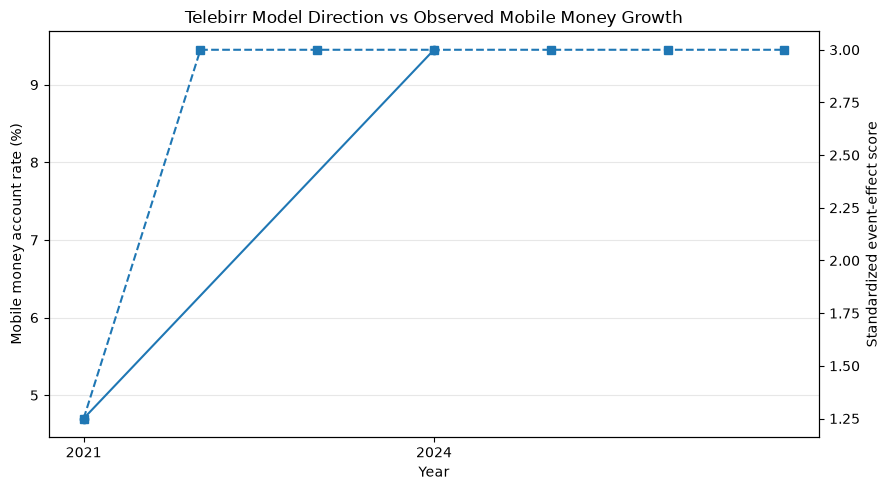

In [54]:
fig, ax1 = plt.subplots(
    figsize=(9, 5)
)

ax1.plot(
    observed_mobile_money["year"],
    observed_mobile_money[
        "mobile_money_account_rate"
    ],
    marker="o",
    label="Observed mobile money rate",
)

ax1.set_xlabel("Year")
ax1.set_ylabel(
    "Mobile money account rate (%)"
)

ax1.set_xticks(
    observed_mobile_money["year"]
)

ax2 = ax1.twinx()

ax2.plot(
    telebirr_annual_effect["year"],
    telebirr_annual_effect[
        "year_end_effect_score"
    ],
    marker="s",
    linestyle="--",
    label="Modeled event-effect score",
)

ax2.set_ylabel(
    "Standardized event-effect score"
)

ax1.set_title(
    "Telebirr Model Direction vs Observed Mobile Money Growth"
)

ax1.grid(
    axis="y",
    alpha=0.3,
)

fig.tight_layout()
plt.show()

In [55]:
if direction_aligned:
    alignment_statement = (
        "The model aligns with the observed direction."
    )
else:
    alignment_statement = (
        "The model does not align with the observed direction."
    )

print(alignment_statement)

The model aligns with the observed direction.


In [56]:
print("=" * 60)
print("HISTORICAL MODEL VALIDATION")
print("=" * 60)

print(
    "\nEvent:",
    "Telebirr Launch",
)

print(
    "Indicator:",
    "ACC_MM_ACCOUNT",
)

print(
    "Observed change:",
    f"{observed_change_pp:.2f} percentage points",
)

print(
    "Modeled direction:",
    modeled_direction,
)

print(
    "Observed direction:",
    observed_direction,
)

print(
    "Direction aligned:",
    direction_aligned,
)

print(
    "\nConclusion:",
    "The model passes a directional check, "
    "but its numerical magnitude remains uncalibrated."
)

HISTORICAL MODEL VALIDATION

Event: Telebirr Launch
Indicator: ACC_MM_ACCOUNT
Observed change: 4.75 percentage points
Modeled direction: increase
Observed direction: increase
Direction aligned: True

Conclusion: The model passes a directional check, but its numerical magnitude remains uncalibrated.


## Refinement of Impact Estimates

In [57]:
refined_impacts = event_indicator_links.copy()

refined_impacts[
    "refined_magnitude"
] = refined_impacts["impact_magnitude"]

refined_impacts[
    "refined_lag_months"
] = refined_impacts["lag_months"]

refined_impacts[
    "estimate_confidence"
] = "low"

refined_impacts[
    "adjustment_reason"
] = "No adjustment; limited supporting evidence."

In [58]:
has_comparable_evidence = (
    refined_impacts[
        "comparable_evidence_id"
    ].notna()
)

refined_impacts.loc[
    has_comparable_evidence,
    "estimate_confidence",
] = "medium"

refined_impacts.loc[
    has_comparable_evidence,
    "adjustment_reason",
] = (
    "Direction supported by comparable-country evidence, "
    "but Ethiopian causal evidence remains limited."
)

### Refine Telebirr estimates

In [59]:
telebirr_ownership_mask = (
    refined_impacts["event_name"]
    .str.contains(
        "Telebirr",
        case=False,
        na=False,
    )
    & (
        refined_impacts["related_indicator"]
        == "ACC_OWNERSHIP"
    )
)

refined_impacts.loc[
    telebirr_ownership_mask,
    "refined_magnitude",
] = "medium"

refined_impacts.loc[
    telebirr_ownership_mask,
    "refined_lag_months",
] = 12

refined_impacts.loc[
    telebirr_ownership_mask,
    "estimate_confidence",
] = "medium"

refined_impacts.loc[
    telebirr_ownership_mask,
    "adjustment_reason",
] = (
    "Reduced from high to medium. Account ownership increased "
    "only 3 percentage points between 2021 and 2024, and many "
    "wallet users may already have bank accounts."
)

In [60]:
telebirr_direct_mask = (
    refined_impacts["event_name"]
    .str.contains(
        "Telebirr",
        case=False,
        na=False,
    )
    & refined_impacts[
        "related_indicator"
    ].isin([
        "USG_P2P_COUNT",
        "USG_TELEBIRR_USERS",
    ])
)

refined_impacts.loc[
    telebirr_direct_mask,
    "estimate_confidence",
] = "medium"

refined_impacts.loc[
    telebirr_direct_mask,
    "adjustment_reason",
] = (
    "Magnitude retained because the event has a direct relationship "
    "with Telebirr users and transaction activity. Exact causal size "
    "cannot be isolated."
)

### Refine M-Pesa estimate

In [61]:
mpesa_account_mask = (
    refined_impacts["event_name"]
    .str.contains(
        "M-Pesa Ethiopia Launch",
        case=False,
        na=False,
    )
    & (
        refined_impacts["related_indicator"]
        == "ACC_MM_ACCOUNT"
    )
)

refined_impacts.loc[
    mpesa_account_mask,
    "refined_magnitude",
] = "medium"

refined_impacts.loc[
    mpesa_account_mask,
    "refined_lag_months",
] = 6

refined_impacts.loc[
    mpesa_account_mask,
    "estimate_confidence",
] = "medium"

refined_impacts.loc[
    mpesa_account_mask,
    "adjustment_reason",
] = (
    "Estimate retained. Mobile money account penetration increased "
    "after M-Pesa entered, but only one post-entry survey point is "
    "available and Telebirr also contributed to market growth."
)

### Refine Fayda’s account ownership effect

In [62]:
fayda_mask = (
    refined_impacts["event_name"]
    .str.contains(
        "Fayda",
        case=False,
        na=False,
    )
    & (
        refined_impacts["related_indicator"]
        == "ACC_OWNERSHIP"
    )
)

refined_impacts.loc[
    fayda_mask,
    "refined_magnitude",
] = "medium"

refined_impacts.loc[
    fayda_mask,
    "refined_lag_months",
] = 24

refined_impacts.loc[
    fayda_mask,
    "estimate_confidence",
] = "low"

refined_impacts.loc[
    fayda_mask,
    "adjustment_reason",
] = (
    "Magnitude and lag retained as a long-term enabling effect. "
    "There is not yet enough Ethiopian post-rollout evidence to "
    "validate the impact on account ownership."
)

In [63]:
interoperability_mask = (
    refined_impacts["event_name"]
    .str.contains(
        "EthSwitch Integration|Interoperable QR",
        case=False,
        na=False,
        regex=True,
    )
)

refined_impacts.loc[
    interoperability_mask,
    "estimate_confidence",
] = "medium"

refined_impacts.loc[
    interoperability_mask,
    "adjustment_reason",
] = (
    "Estimate retained. Comparable evidence supports a positive "
    "effect of interoperability on transaction activity, although "
    "the Ethiopian effect size is not directly measured."
)

In [64]:
indirect_event_mask = (
    refined_impacts["event_name"]
    .str.contains(
        "ISO 20022|Digital Payments Strategy|Financial Education",
        case=False,
        na=False,
        regex=True,
    )
)

refined_impacts.loc[
    indirect_event_mask,
    "estimate_confidence",
] = "low"

refined_impacts.loc[
    indirect_event_mask,
    "adjustment_reason",
] = (
    "Retained as an enabling relationship. The event may improve "
    "market conditions, but no direct Ethiopian pre/post estimate "
    "is available."
)

### Recalculate refined scores

In [65]:
refined_impacts[
    "refined_magnitude_score"
] = (
    refined_impacts[
        "refined_magnitude"
    ]
    .str.lower()
    .map(magnitude_scores)
)

refined_impacts[
    "refined_effect_score"
] = (
    refined_impacts[
        "direction_score"
    ]
    * refined_impacts[
        "refined_magnitude_score"
    ]
)

In [66]:
adjusted_impacts = refined_impacts[
    (
        refined_impacts[
            "impact_magnitude"
        ]
        != refined_impacts[
            "refined_magnitude"
        ]
    )
    |
    (
        refined_impacts[
            "lag_months"
        ]
        != refined_impacts[
            "refined_lag_months"
        ]
    )
].copy()

adjusted_impacts[
    [
        "event_name",
        "related_indicator",
        "impact_magnitude",
        "refined_magnitude",
        "lag_months",
        "refined_lag_months",
        "signed_effect_score",
        "refined_effect_score",
        "estimate_confidence",
        "adjustment_reason",
    ]
]

,event_name,related_indicator,impact_magnitude,refined_magnitude,lag_months,refined_lag_months,signed_effect_score,refined_effect_score,estimate_confidence,adjustment_reason
0,Telebirr Launch,ACC_OWNERSHIP,high,medium,12,12,3,2,medium,Reduced from high to medium. Account ownership...


### refined association matrix

In [67]:
refined_association_matrix = (
    refined_impacts[
        refined_impacts[
            "related_indicator"
        ].isin(key_indicators)
    ]
    .pivot_table(
        index=[
            "parent_id",
            "event_name",
        ],
        columns="related_indicator",
        values="refined_effect_score",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(
        columns=key_indicators,
        fill_value=0,
    )
    .reset_index()
)

refined_association_matrix

related_indicator,parent_id,event_name,ACC_OWNERSHIP,ACC_MM_ACCOUNT,ACC_4G_COV,ACC_FAYDA,USG_DIGITAL_PAYMENT_RATE,USG_P2P_COUNT,USG_ACTIVE_RATE,USG_SECTOR_ACTIVE_ACCOUNT_RATE,USG_POS_COUNT,USG_DIGITAL_TXN_VALUE
0,EVT_0001,Telebirr Launch,2,0,0,0,0,3,0,0,0,0
1,EVT_0002,Safaricom Ethiopia Commercial Launch,0,0,2,0,0,0,0,0,0,0
2,EVT_0003,M-Pesa Ethiopia Launch,0,2,0,0,0,0,0,0,0,0
3,EVT_0004,Fayda Digital ID Program Rollout,2,0,0,0,0,0,0,0,0,0
4,EVT_0007,M-Pesa EthSwitch Integration,0,0,0,0,0,2,0,0,0,0
5,EVT_0008,EthioPay Instant Payment System Launch,0,0,0,0,0,2,0,0,0,0
6,EVT_0011,Revised Payment Instrument Issuer Directive,0,2,0,0,0,0,0,2,0,0
7,EVT_0012,National Financial Education Module Launch,0,0,0,0,1,0,0,0,0,0
8,EVT_0013,National Interoperable QR Payment Standard Launch,0,0,0,0,2,0,0,0,2,0
9,EVT_0014,National Digital Payments Strategy Phase Two L...,2,0,0,0,2,0,0,0,0,0


In [68]:
confidence_summary = (
    refined_impacts[
        "estimate_confidence"
    ]
    .value_counts()
    .rename_axis(
        "confidence"
    )
    .reset_index(
        name="impact_link_count"
    )
)

confidence_summary

,confidence,impact_link_count
0,low,13
1,medium,10


In [69]:
refined_estimate_summary = refined_impacts[
    [
        "event_name",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "refined_magnitude",
        "lag_months",
        "refined_lag_months",
        "refined_effect_score",
        "estimate_confidence",
        "adjustment_reason",
    ]
].sort_values(
    [
        "estimate_confidence",
        "event_name",
    ]
)

refined_estimate_summary

,event_name,related_indicator,impact_direction,impact_magnitude,refined_magnitude,lag_months,refined_lag_months,refined_effect_score,estimate_confidence,adjustment_reason
9,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,increase,medium,medium,24,24,2,low,Magnitude and lag retained as a long-term enab...
10,Fayda Digital ID Program Rollout,GEN_GAP_ACC,decrease,medium,medium,24,24,-2,low,No adjustment; limited supporting evidence.
14,Foreign Exchange Liberalization,AFF_DATA_INCOME,increase,high,high,3,3,3,low,No adjustment; limited supporting evidence.
17,ISO 20022 EATS Payment System Upgrade,USG_DIGITAL_TXN_VALUE,increase,low,low,6,6,1,low,Retained as an enabling relationship. The even...
18,ISO 20022 EATS Payment System Upgrade,USG_P2P_COUNT,increase,low,low,12,12,1,low,Retained as an enabling relationship. The even...
6,M-Pesa Ethiopia Launch,USG_MPESA_USERS,increase,high,high,3,3,3,low,No adjustment; limited supporting evidence.
15,National Digital Payments Strategy Phase Two L...,ACC_OWNERSHIP,increase,medium,medium,12,12,2,low,Retained as an enabling relationship. The even...
16,National Digital Payments Strategy Phase Two L...,USG_DIGITAL_PAYMENT_RATE,increase,medium,medium,12,12,2,low,Retained as an enabling relationship. The even...
11,National Financial Education Module Launch,USG_DIGITAL_PAYMENT_RATE,increase,low,low,12,12,1,low,Retained as an enabling relationship. The even...
8,Revised Payment Instrument Issuer Directive,USG_SECTOR_ACTIVE_ACCOUNT_RATE,increase,medium,medium,12,12,2,low,No adjustment; limited supporting evidence.


In [70]:
print("=" * 60)
print("REFINED EVENT IMPACT ESTIMATES")
print("=" * 60)

print(
    "\nTotal impact links:",
    len(refined_impacts),
)

print(
    "Magnitude or lag adjustments:",
    len(adjusted_impacts),
)

print(
    "\nConfidence distribution:"
)

print(
    confidence_summary.to_string(
        index=False
    )
)

print(
    "\nMain adjustment:"
)

print(
    "Telebirr → ACC_OWNERSHIP changed from "
    "high (+3) to medium (+2)."
)

print(
    "\nReason:"
)

print(
    "Account ownership increased only 3 percentage points "
    "from 2021 to 2024, while Telebirr's stronger effects "
    "appear in users and transaction activity."
)

REFINED EVENT IMPACT ESTIMATES

Total impact links: 23
Magnitude or lag adjustments: 1

Confidence distribution:
confidence  impact_link_count
       low                 13
    medium                 10

Main adjustment:
Telebirr → ACC_OWNERSHIP changed from high (+3) to medium (+2).

Reason:
Account ownership increased only 3 percentage points from 2021 to 2024, while Telebirr's stronger effects appear in users and transaction activity.
